Handling Mixed Value

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [59]:
df = pd.read_csv('titanic.csv')

In [60]:
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


Handle Number Column in Dataset

In [61]:
df['number'].unique()

array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

Text(0.5, 1.0, 'Passengers travelling with')

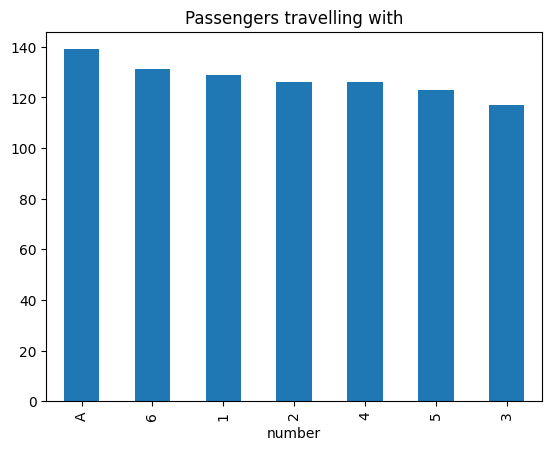

In [62]:
fig = df['number'].value_counts().plot.bar()
fig.set_title('Passengers travelling with')

In [63]:
df['num_numeric'] = pd.to_numeric(df["number"],errors='coerce',downcast='integer')
df['num_categorical'] = np.where(df['num_numeric'].isnull(),df['number'],'Yes')
df.head()

,Cabin,Ticket,number,Survived,num_numeric,num_categorical
0,NaN,A/5 21171,5,0,5.0,Yes
1,C85,PC 17599,3,1,3.0,Yes
2,NaN,STON/O2. 3101282,6,1,6.0,Yes
3,C123,113803,3,1,3.0,Yes
4,NaN,373450,A,0,NaN,A


Now handle Cabin Column

In [64]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [66]:
df['cabin_num'] = df['Cabin'].str.extract('(\d+)') # captures numerical part
df['cabin_cat'] = df['Cabin'].str[0] # captures the first letter

df.sample(5)


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_627/2186420015.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['cabin_num'] = df['Cabin'].str.extract('(\d+)') # captures numerical part


,Cabin,Ticket,number,Survived,num_numeric,num_categorical,cabin_num,cabin_cat
96,A5,PC 17754,A,0,NaN,A,5,A
599,A20,PC 17485,3,1,3.0,Yes,20,A
197,NaN,4579,6,0,6.0,Yes,NaN,NaN
502,NaN,330909,6,0,6.0,Yes,NaN,NaN
154,NaN,Fa 265302,A,0,NaN,A,NaN,NaN


<Axes: xlabel='cabin_cat'>

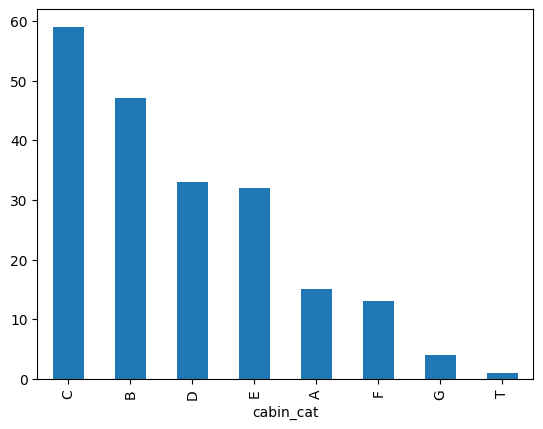

In [69]:
df['cabin_cat'].value_counts().plot(kind='bar')

Now handle Tickets

In [68]:
df['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [71]:
# extract the last bit of ticket as number
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num'] = pd.to_numeric(df['ticket_num'],
                                   errors='coerce',
                                   downcast='integer')

# extract the first part of ticket as category
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan,
                              df['ticket_cat'])


In [72]:

df.head(10)

,Cabin,Ticket,number,Survived,num_numeric,num_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,Yes,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,Yes,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,Yes,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,Yes,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN
5,NaN,330877,2,0,2.0,Yes,NaN,NaN,330877.0,NaN
6,E46,17463,2,0,2.0,Yes,46,E,17463.0,NaN
7,NaN,349909,5,0,5.0,Yes,NaN,NaN,349909.0,NaN
8,NaN,347742,1,1,1.0,Yes,NaN,NaN,347742.0,NaN
9,NaN,237736,A,1,NaN,A,NaN,NaN,237736.0,NaN


<Axes: xlabel='ticket_cat'>

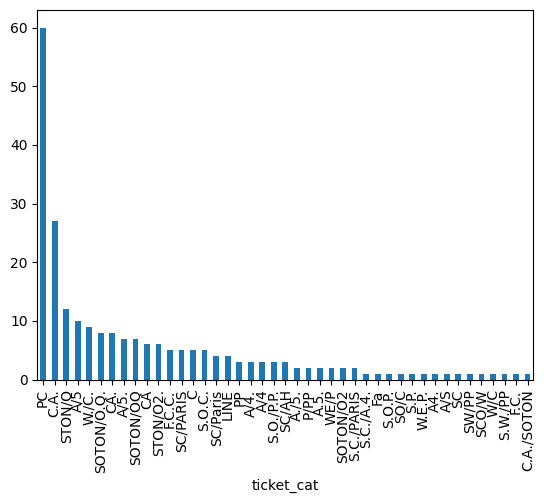

In [75]:
df['ticket_cat'].value_counts().plot(kind='bar')